Etapa 1 del proyecto. La tarea de regresión: Implementación de modelos polinomiales y regresión Lasso con regularización.

A. Objetivos.

Aplicar técnicas de regresión para construir un modelo predictivo que permita estimar la demanda sobre el uso de un sistema de alquiler de bicicletas siguiendo el ciclo de machine learning.

Determinar cuáles son los factores que más inciden en la demanda con base en los datos

Omar Diaz

In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive, files
from mlxtend.plotting import heatmap, scatterplotmatrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, RobustScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from importlib.metadata import version

Revisión de algunas versiones de las actuales librerias consideras en el notebook

In [ ]:
print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Scikit-learn: {version('scikit-learn')}")
print(f"Versión de NumPy: {version('numpy')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de mlxtend: {version('mlxtend')}")
print(f"Versión de Google Colab: {version('google-colab')}")
print(f"Versión de Importlib: {version('importlib-metadata')}")
print(f"Versión de Seaborn: {version('seaborn')}")
print(f"Versión de Statsmodels: {version('statsmodels')}")

Versión de Pandas: 2.2.2
Versión de Scikit-learn: 1.6.1
Versión de NumPy: 1.26.4
Versión de Matplotlib: 3.10.0
Versión de mlxtend: 0.23.4
Versión de Google Colab: 1.0.0
Versión de Importlib: 8.6.1
Versión de Seaborn: 0.13.2
Versión de Statsmodels: 0.14.4


Montaje de disco en el ambiente donde residen los datos (herramienta Google Drive MyDRive/Data). Por facilidad decide montar el notebook en Google Colab. **Es importante mencionar que cuando el file vaya a ser evaluado debe ser cambiada la ruta de acceso al archivo de fuente de datos.**

In [ ]:
#montage del disco drive
drive.mount('/content/drive', force_remount=True)
# una vez se montó el drive, se cambia la ruta de archivo de 'content' de Colab por la ruta de Google Drive ('/MyDrive/datos/')
os.chdir('/content/drive/MyDrive/Data/')

Mounted at /content/drive


#1. Exploración y perfilamiento de los datos. Se cargan los datos desde el repositorio central y luego se realiza la exploración y perfilamiento


In [ ]:
#Cargue de los datos del archivo fuente en el Data Frame datos_crudos
datos_crudos = pd.read_csv('./Datos_Etapa-1.csv', sep=',')
#visualización de los ´primeros datos
datos_crudos.head()

,season,weekday,weathersit,temp,atemp,hum,windspeed,cnt,time_of_day
0,Winter,6,Clear,3.28,3.0014,0.81,0.0,16,Night
1,Winter,6,Clear,2.34,1.9982,0.80,0.0,40,Night
2,Winter,6,Clear,2.34,1.9982,0.80,0.0,32,Night
3,Winter,6,Clear,3.28,3.0014,0.75,0.0,13,Night
4,Winter,6,Clear,3.28,3.0014,0.75,0.0,1,Night


Luego de una revisión del archivo de diccionario de datos, se observa que existen 4 variables dependientes de tipo cuantitativo nominal. Por lo cual, estas deberán tener un tratamiento de datos previo antes de ser procesadas por los algoritmos objetivo de este proyecto. Haciendo un análisis exploratorio sobre las variables cuantitativas, tenemos:

- Las variables de Temperatura y Sensación Térmica presentan una relación más
directa que las otras variables.
- Humedad presenta una representación bastante consistente, con algunas observaciones de pequeños outliers.
- La variable Velocidad muestra un conjunto de datos que se encuentra fuera del rango del universo. En este sentido, se realizó una consulta para identificar la cantidad de registros con valor "cero" y se encontró un resultado del 12% sobre el total de la variable. Aunque se investigó que es posible tener medidas de velocidad de viento, sería importante validar este punto con los dueños de estos datos.

In [176]:
#Definimos un arreglo donde almacenemos las inciales de los nombre de las variable numericas
cols_categoricas = ['season', 'weathersit', 'time_of_day']
cols_numericas =list(set(datos_crudos.columns) - set(cols_categoricas))
#Hacemos un describe de las variables numericas
#datos_crudos = datos_crudos.reset_index(drop=True)
datos_crudos[cols_numericas].describe()


,cnt,hum,temp,atemp,weekday,windspeed
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,189.463088,0.627229,15.358397,15.401157,3.003683,12.736540
std,181.387599,0.192930,9.050138,11.342114,2.005771,8.196795
min,1.000000,0.000000,-7.060000,-16.000000,0.000000,0.000000
25%,40.000000,0.480000,7.980000,5.997800,1.000000,7.001500
50%,142.000000,0.630000,15.500000,15.996800,3.000000,12.998000
75%,281.000000,0.780000,23.020000,24.999200,5.000000,16.997900
max,977.000000,1.000000,39.000000,50.000000,6.000000,56.996900


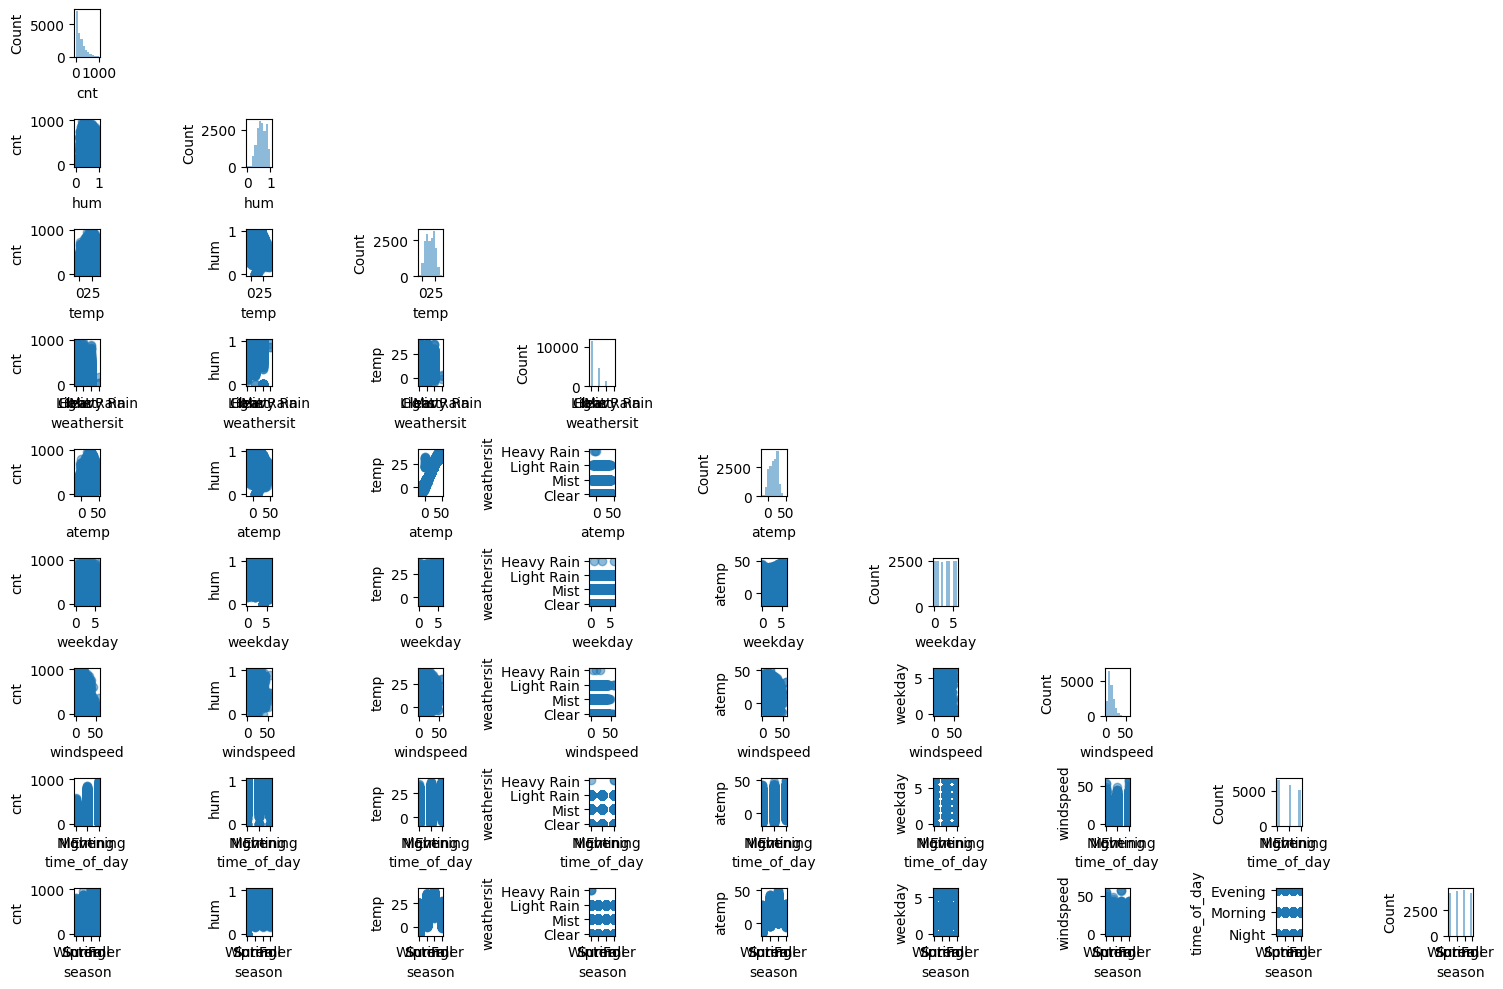

In [168]:
#Definimos una nueva variable para almacenar la variable que vamos a diseñar con graficos de dispersión. Esto para las variable numericas.
cols_scatter = cols_numericas
scatterplotmatrix(datos_crudos[cols_scatter].values, figsize=(15, 10),
names=cols_numericas, alpha=0.5)
plt.tight_layout()
plt.show()

Respecto a las variables categoricas podemos decir los siguiente
- Sobre el conjunto de datos en estaciones específicas donde se realizan alquileres de bicicletas, no se alcanza a observar una tendencia marcada sobre alguna estación en particular.
- A diferencia de la variable Estación, la variable Clima sí marca una diferencia o preferencia por climas despejados, y baja preferencia en climas de alta lluvia.
- Por último, la variable Parte del Día marca una preferencia por alquiler de bicicletas en la noche.

Vale la oportunidad para aclarar que este count es solo la veces que fueron compradas bicicletas mas no el numero de bicicletas compradas.

In [ ]:
#Agrupamos y contamos por el campo season
pd.Series(datos_crudos['season']).value_counts()

,count
season,
Summer,4496
Spring,4409
Winter,4242
Fall,4232


In [ ]:
#Agrupamos y contamos por el campo weathersit
pd.Series(datos_crudos['weathersit']).value_counts()

,count
weathersit,
Clear,11413
Mist,4544
Light Rain,1419
Heavy Rain,3


In [ ]:
#Agrupamos y contamos por el campo weathersit
pd.Series(datos_crudos['time_of_day']).value_counts()

,count
time_of_day,
Night,6471
Morning,5805
Evening,5103


Como parte del análisis de la influencia que puedan tener las variables dependientes sobre la variable objetivo, tenemos:

- Día: Este es una variable categorica ordinal. Por esta no es considerada para el analisis de calculo de coeficientes.
- Temperatura: Tiene un valor importante de influencia sobre la variable dependiente. Adicionalmente, tiene el mismo valor de coeficiente que Sensación Térmica, lo que nos lleva a confirmar que es posible dejar solo una de estas dos variables. Para nuestro ejercicio, dejaremos Temperatura.
- Sensación Térmica: Igual que Temperatura, será una de las variables a eliminar.
- Humedad: Tiene un valor importante en su coeficiente, aunque es negativo. Esto nos lleva a decir que los días de aumento en la humedad, baja el número de bicicletas alquiladas.

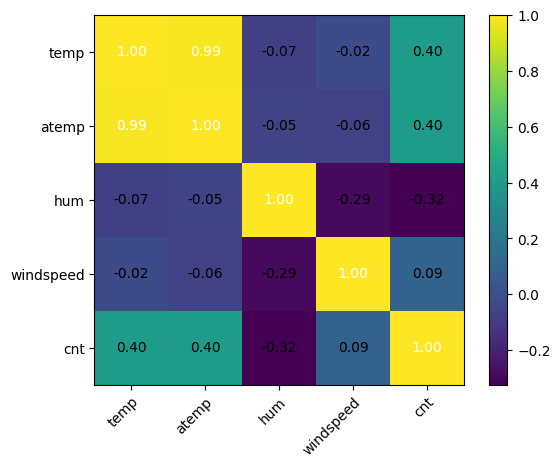

In [ ]:
#Grafica de Mapa de calor con los coeficientes de la variables cuantitativas.
# Definimos col, para poder calcular el mapa de calor para las variable numericas a exepcion de la varibles día.
cols = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']
cm = np.corrcoef(datos_crudos[cols].values.T)
hm = heatmap(cm,row_names=cols, column_names=cols, cell_font_size=10)
plt.tight_layout
plt.show()

#2.Limpieza y preparación de los datos sobre los dataframe cargados
De manera general a nivel de registro se tiene lo siguiente:
*   Instancias: No se encontraron registro faltantes, pero si se encuentraron 42 registros duplicados.

In [ ]:
# Busqueda de registros faltantes sobre el data frame.
datos_crudos.isna().sum()

,0
season,0
weekday,0
weathersit,0
temp,0
atemp,0
hum,0
windspeed,0
cnt,0
time_of_day,0


A nivel de duplicación se encontran un total de 42 datos repetivos, lo cual es un % bajo (0.2) respecto a todo la muestra de datos.

In [ ]:
#Busqueda de registro duplicados sobre el dataframe.
datos_crudos.duplicated().sum()

42

In [173]:
# Partición de los datos, en datos de entraminamiento y pruebas (proporsión 80/20), de las variables independiente y dependientes en ambos casos.
train, test = train_test_split(datos_crudos, test_size=0.2, random_state=77)
train = train.reset_index(drop=True)
#x_test = x_test.reset_index(drop=True)

In [177]:
datos_categoricos = x_train[cols_categoricas]
#cols_numericas = ['temp',  'hum', 'windspeed']
#datos_numericos = x_train[cols_numericas]
encoder = OneHotEncoder(sparse_output=False)
encoder.fit(datos_categoricos)
pd.DataFrame(encoder.get_feature_names_out(),columns=["Variable"])
x_train.shape

KeyError: "None of [Index(['season', 'weathersit', 'time_of_day'], dtype='object')] are in the [columns]"

In [ ]:
# Eliminación de los 42 registro duplicados y se asigna a nuevo data frame para manetener los datos crudos en este mismo data frame.
datos = datos_crudos.drop_duplicates()

Transformación de la variables categoricas

In [ ]:
# OneHotEncoder para transformar las variables categóricas a numéricas usando la función transform
x_train_categoricas_onehot = pd.DataFrame(encoder.transform(datos_categoricos),columns=encoder.get_feature_names_out())
x_train_categoricas_onehot.head()
x_train_categoricas_onehot.shape


In [ ]:
# Se concatenan los datos numericos y los datos categoricos
x_train = pd.concat([datos_numericos, x_train_categoricas_onehot],axis="columns")
x_train.shape
#x_train.head()

In [ ]:
# Eliminación de la variable de Cantidad y Sensación Termica del dataframe para crear el conjunto de datos nuevo de variables dependientes.
x_train = datos.drop(['cnt','atemp'], axis="columns")
# Datos de variable dependiente
y_train = datos['cnt']

#3. Construcción de un modelo de regresión polinomial. Para este caso se ha empleado la técnica de selección de modelos cross-validation que permite Promediar los resultados  para obtener una estimación más robusta del rendimiento del modelo.

In [ ]:
# Se decidio usar RobustScaler debido a que fueron encontratos algunos valores atipicos en algunas variables dependientes. Luego es creado un pipeline.
scaler_poly = RobustScaler()
polynomial_regression = make_pipeline(
    PolynomialFeatures(),
    scaler_poly,
    LinearRegression()
)

In [ ]:
# Uso de KFold como herramienta para el uso de modelo de cross validation.
kfold = KFold(n_splits=10, shuffle=True, random_state = 0)

In [ ]:
# Definicón de parametros de nivel del polinomio como parte de la seleccion de modelos que queremos que se realice.
valores = [2, 3]
param_grid = {'polynomialfeatures__degree': valores}

In [ ]:
# Uso de la función GridSearchCV para la automación de esta seleccion del mejor modelo.
grid = GridSearchCV(polynomial_regression, param_grid, cv=kfold)
x_train.shape
#y_train.shape

In [ ]:
# Ajuste para la seleccion del mejor modelo tomando como parametro del variables dependientes e indendientes del conjunto de entrenamiento.
grid.fit(x_train,y_train)
# Resultado del calculo del mejor modelo dentro de la opciones dadas 2/3.
#print("Mejor parámetro: ", grid.best_params_)
#x_train.describe()
#x_train.describe()

Como resultado del mejor hiper parametro la funcion GridSearchCV logro arroja que el mejor modelo es la regresión de polinomio de grado 3.

In [ ]:
# Resutaldo del mejor modelo y es asigando a la variable mejor_modelo
mejor_modelo = grid.best_estimator_
# Listado complete los coeficientes calculados y su nombre
list(zip(x_train.columns, mejor_modelo.named_steps['linearregression'].coef_))

In [ ]:
# Preddicón de la varaible dependiente para el conjunto de datos de prueba.
y_pred = mejor_modelo.predict(x_test)

In [ ]:
#Calculo de las metricas de medicion de este modelo.
rmse_poly = root_mean_squared_error(y_test, y_pred)
print("RMSE: ", rmse_poly)
mae_poly= mean_absolute_error(y_test, y_pred)
print("MAE: ", mae_poly)
r2_poly = r2_score(y_test, y_pred)
print('R²: ', r2_poly)

#4. Construcción de un modelo de regresión regularizada Lasso.

In [ ]:
scaler_lasso = RobustScaler()
columns = x_train.columns
# Son transformadas las variable dependientes.
x_train = scaler_lasso.fit_transform(x_train)
x_train = pd.DataFrame(x_train, columns=columns)
# Uso de objeto lasso
lasso = Lasso()

In [ ]:
#Definción del espacio de búsqueda del mejor hiperparametro alpha entre la opciones dadas.
valores = [1, 2, 3, 4, 5]
param_grid = {'alpha':valores}

In [ ]:
# Búsqueda de hiperparámetros con la funcion GridSearchCV y obtención de coefientes y sus nombres.
grid = GridSearchCV(lasso,param_grid, cv =kfold)
grid.fit(x_train, y_train)
print("Mejor parámetro: ", grid.best_params_)
mejor_modelo_lasso = grid.best_estimator_
list(zip(x_train.columns, mejor_modelo_lasso.coef_))

**Evaluación del modelo**

Estandarización de los datos del conjunto de pruebas unicamente con la opción transform ya que el modelo ya se encuetra entrenado.

In [ ]:
# Transformacion del conjunto de datos de prueba para las variable dependientes.
x_test = scaler_lasso.transform(x_test)
x_test = pd.DataFrame(x_test, columns=columns)

In [ ]:
# Predicciones con el fin de compararlas con los valores reales almacenados en y_test
y_pred = mejor_modelo_lasso.predict(x_test)

In [ ]:
#Métricas de rendimiento utilizando las predicciones del modelo
rmse_lasso = root_mean_squared_error(y_test, y_pred)
print("RMSE: ", rmse_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred)
print("MAE: ", mae_lasso)
r2_lasso=r2_score(y_test, y_pred)
print('R²: ', r2_lasso)

#5. Elaboración de una tabla comparativa mostrando el rendimiento sobre test de los dos modelos seleccionados (con mejores rendimientos) de las actividades 3 y 4, con las métricas R2, RMSE y MAE

In [ ]:
resultados = {
    'Modelo': ['Modelo Regresion Polinomial', 'Modelo Regresión Regularizada Lasso'],
    'R²': [r2_poly, r2_lasso],
    'RMSE': [rmse_poly, rmse_lasso],
    'MAE': [mae_poly, mae_lasso]
}
pd.DataFrame(resultados)

#6 Con base en el modelo Lasso determinar las variables más importantes para la predicción

In [ ]:
lasso_sv = Lasso(alpha=10)
lasso_sv.fit(x_train, y_train)
pd.DataFrame(zip(x_train.columns, lasso_sv.coef_),columns=["Variable","Coeficiente"])

La identificación de las variables mas representativas serían TEMP, HUMEDAD, PART DIA_Evening, PART DIA_Night. Esto lo logramos llevando el hiperparametro alpah a 5, donde son regulaizadas la variables con un valor importante y solo quedan las variable que tiene una mayor indencia sobre la variable dependiente.

E. Análisis de resultados.
Una vez construido los modelos, deberías estar en capacidad de responder estas preguntas:

¿Cuál es el grado de la transformación polinomial que fue seleccionado utilizando la técnica de validación?

Respuesta: 3

¿Cuál fue el valor de α que fue seleccionado utilizando la técnica de validación para la regresión Lasso?

Respuesta: 1

A partir de la tabla comparativa, ¿cuál modelo ofrece el mejor rendimiento sobre el conjunto test?
El modelo que mejor rendimiento da sobre el conjunt ode test el polinomial grado 3

¿Qué interpretación puedes darles a los valores obtenidos sobre las métricas de rendimiento?
De acuerdo a la metricas obtenidas, podemos indicar que el mejor modelo es el polinomial debido a que tovo un mejor resultado en el calculo de la metrica R2. Aunque el modelo de Lasso tuvo un mejor resultado con el alpha de 1, aparamente este ajusto bien en el modelo de entrenamiento, pero en el modelo de pruebas no logra su generalización.

¿Cuáles variables fueron seleccionadas con el modelo Lasso? A partir de estas, ¿qué interpretación de cara al problema puedes dar? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.

De cara al problema, existen variables como la Temperatura, Humedad, part día en otras mencionas anteriomente, que son variables importantes dentro del conjunto de datos, que bajo el metodo de seleccion de lasso pudimos descubir, y que represetan una influencia importante para el calculo de la varaible dependiente (cantidad de bicicletas). La predicción de la demanda de bicicletas aportará a la prestación de un mejor servicio para predecir la cantidad de bicicletas sobre la demada. De la misma forma poder colocar la cantidad de bicicletas en lugar y tiempo preciso donde estas sean requeridas, representarán un servicio mas eficiente.